# FPbase clustering explorer

Load the processed FPbase `(sequence, spectrum)` dataset and **explore how the sequences cluster** before
committing to a train/test split. Fluorescent proteins are dominated by a few ancestral families
(avGFP, DsRed, ...), so a random split leaks near-duplicates across train/test. This notebook lets you:

1. inspect the dataset (spectral ranges, lengths, organisms, duplicates),
2. compute sequence similarity and **sweep a clustering threshold**,
3. compare identity clusters against name-family and organism groupings,
4. preview what a cluster-aware split would look like — **without committing anything**.

> Similarity here is a fast, alignment-free **k-mer containment** proxy for % identity (good for
> exploration). For the final committed split, recompute clusters with MMseqs2/CD-HIT (command at the end).

## 0. Setup

In [1]:
import csv, os, re, math
from collections import defaultdict, Counter
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False
    print("matplotlib not found - plots skipped")

DATA_DIR = os.path.join("..", "fpbase-extractor", "processed_data", "ESM-spectrum")
print("data dir:", os.path.abspath(DATA_DIR))

data dir: /Users/zhengqing/PyProjects/fpbase-extractor/processed_data/ESM-spectrum


In [2]:
spectra = np.load(os.path.join(DATA_DIR, "spectra.npy"))     # (N, 2G)
grid    = np.load(os.path.join(DATA_DIR, "grid_nm.npy"))     # (G,)
rows    = list(csv.DictReader(open(os.path.join(DATA_DIR, "metadata.csv"))))
seqs    = [r["seq"] for r in rows]
G = len(grid); N = len(seqs)

ex_max = np.array([float(r["ex_max"]) for r in rows])
em_max = np.array([float(r["em_max"]) for r in rows])
lengths = np.array([len(s) for s in seqs])
seq_group = np.array([int(r["seq_group"]) for r in rows])

print(f"N = {N} samples | {len(set(seq_group))} unique sequences "
      f"({N - len(set(seq_group))} exact-duplicate rows)")
print(f"spectrum dim {spectra.shape[1]} (ex[0:{G}] + em[{G}:{2*G}]) | grid {grid[0]:.0f}-{grid[-1]:.0f} nm")
print(f"ex_max {ex_max.min():.0f}-{ex_max.max():.0f} nm | em_max {em_max.min():.0f}-{em_max.max():.0f} nm")
print(f"length {lengths.min()}-{lengths.max()} (median {int(np.median(lengths))})")

N = 453 samples | 430 unique sequences (23 exact-duplicate rows)
spectrum dim 1002 (ex[0:501] + em[501:1002]) | grid 300-800 nm
ex_max 338-702 nm | em_max 414-720 nm
length 106-476 (median 237)


## 1. Dataset overview

Where the proteins sit in spectral space, how long they are, and the coarse metadata (oligomerization,
switching, organism) that could also drive a split.

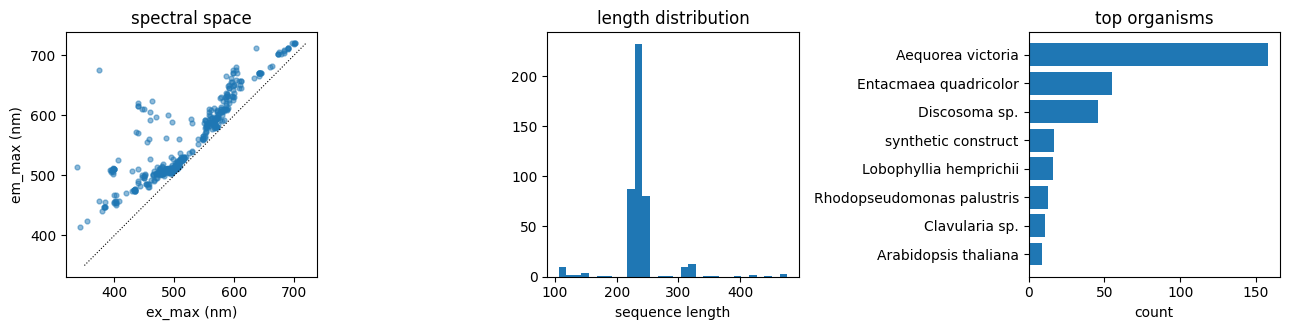

switch types: {'basic': 383, 'photoconvertible': 38, 'photoswitchable': 20, 'photoactivatable': 5, 'multistate': 1, '(none)': 1, 't': 2, 'other': 3}
oligomerization: {'monomer': 225, '(unknown)': 112, 'dimer': 51, 'tetramer': 33, 'weak dimer': 28, 'tandem dimer': 4}


In [3]:
if HAVE_PLT:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
    ax[0].scatter(ex_max, em_max, s=12, alpha=0.5)
    ax[0].plot([350, 720], [350, 720], "k:", lw=0.8)
    ax[0].set_xlabel("ex_max (nm)"); ax[0].set_ylabel("em_max (nm)"); ax[0].set_title("spectral space")
    ax[1].hist(lengths, bins=30); ax[1].set_xlabel("sequence length"); ax[1].set_title("length distribution")
    org = Counter(r["parent_organism"] or "(unknown)" for r in rows).most_common(8)
    ax[2].barh([o for o, _ in org][::-1], [c for _, c in org][::-1])
    ax[2].set_title("top organisms"); ax[2].set_xlabel("count")
    plt.tight_layout(); plt.show()

print("switch types:", dict(Counter(r["switch_type"] or "(none)" for r in rows)))
print("oligomerization:", dict(Counter(r["oligomerization"] or "(unknown)" for r in rows).most_common(6)))

## 2. Sequence similarity (identity proxy)

Each sequence becomes its set of **k-mers** (default k=3). Similarity between two sequences is the
**containment** = shared k-mers / min(k-mer count) — 1.0 for near-duplicates, ~0 for unrelated proteins.
This is alignment-free and fast (one matrix multiply), and tracks % identity closely enough to explore
cluster structure.

In [4]:
def kmer_sim_matrix(seqs, k=3):
    """N x N k-mer containment similarity in [0,1]."""
    vocab = {}; per_seq = []
    for s in seqs:
        kms = {s[i:i+k] for i in range(len(s) - k + 1)}
        per_seq.append([vocab.setdefault(m, len(vocab)) for m in kms])
    P = np.zeros((len(seqs), len(vocab)), dtype=np.float32)
    for i, idx in enumerate(per_seq):
        P[i, idx] = 1.0
    inter = P @ P.T
    sizes = P.sum(1)
    S = inter / np.maximum(np.minimum.outer(sizes, sizes), 1.0)
    np.fill_diagonal(S, 1.0)
    return S

K = 3
S = kmer_sim_matrix(seqs, K)
print(f"similarity matrix {S.shape} (k={K})")

similarity matrix (453, 453) (k=3)


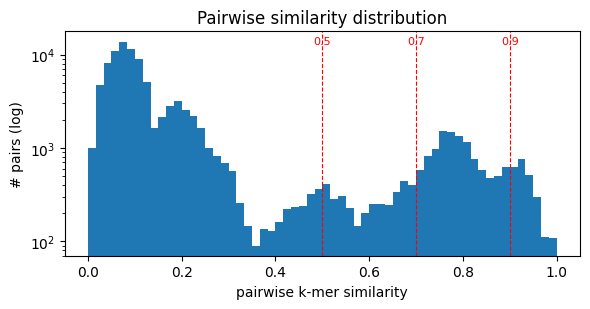

most pairs are dissimilar (left spike); the right tail = within-family near-duplicates


In [5]:
if HAVE_PLT:
    od = S[np.triu_indices(N, 1)]
    plt.figure(figsize=(6, 3.2))
    plt.hist(od, bins=60)
    for thr in (0.5, 0.7, 0.9):
        plt.axvline(thr, color="r", ls="--", lw=0.8)
        plt.text(thr, plt.ylim()[1]*0.9, f"{thr}", color="r", fontsize=8, ha="center")
    plt.xlabel("pairwise k-mer similarity"); plt.ylabel("# pairs (log)"); plt.yscale("log")
    plt.title("Pairwise similarity distribution"); plt.tight_layout(); plt.show()
    print("most pairs are dissimilar (left spike); the right tail = within-family near-duplicates")

## 3. Clustering: sweep the threshold

Single-linkage clustering — connect any two sequences with similarity >= threshold, then take connected
components. **Lower threshold = bigger, fewer clusters (whole families merge); higher = many small clusters
(only near-duplicates group).** Watch how the cluster count and the largest family change.

thr=0.30  clusters= 32  largest=195  singletons= 12
thr=0.35  clusters= 40  largest=181  singletons= 17
thr=0.40  clusters= 45  largest=165  singletons= 18
thr=0.45  clusters= 46  largest=165  singletons= 19
thr=0.50  clusters= 48  largest=165  singletons= 21
thr=0.55  clusters= 51  largest=165  singletons= 23
thr=0.60  clusters= 60  largest=160  singletons= 26
thr=0.65  clusters= 64  largest=159  singletons= 28
thr=0.70  clusters= 70  largest=159  singletons= 30
thr=0.75  clusters= 74  largest=159  singletons= 33
thr=0.80  clusters= 86  largest=155  singletons= 44
thr=0.85  clusters=104  largest=150  singletons= 54
thr=0.90  clusters=132  largest= 90  singletons= 77
thr=0.95  clusters=213  largest= 49  singletons=149
thr=1.00  clusters=424  largest=  3  singletons=397


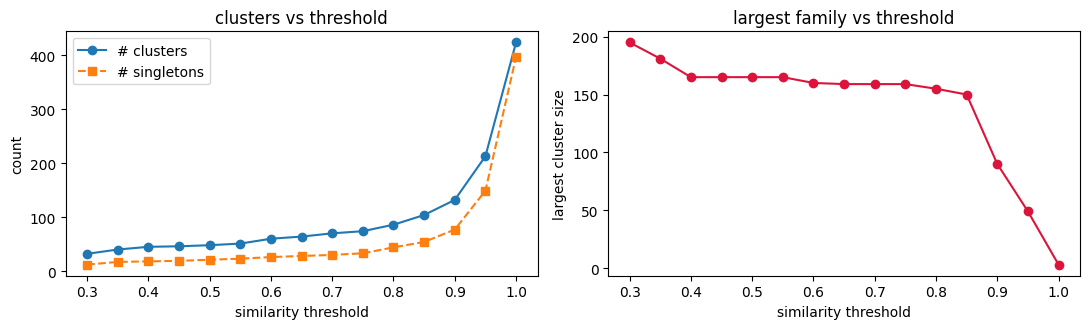

In [6]:
def cluster_at(S, thr):
    """Single-linkage clusters at similarity >= thr. Returns list of index-lists."""
    n = len(S); parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for i, j in np.argwhere(np.triu(S >= thr, 1)):
        ri, rj = find(int(i)), find(int(j))
        if ri != rj: parent[ri] = rj
    comp = defaultdict(list)
    for i in range(n): comp[find(i)].append(i)
    return sorted(comp.values(), key=len, reverse=True)

thr_grid = np.round(np.arange(0.3, 1.001, 0.05), 2)
sweep = []
for thr in thr_grid:
    cl = cluster_at(S, thr)
    sizes = [len(c) for c in cl]
    sweep.append((thr, len(cl), max(sizes), sum(s == 1 for s in sizes)))
    print(f"thr={thr:.2f}  clusters={len(cl):3d}  largest={max(sizes):3d}  singletons={sum(s==1 for s in sizes):3d}")

if HAVE_PLT:
    sw = np.array(sweep)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].plot(sw[:,0], sw[:,1], "o-", label="# clusters")
    ax[0].plot(sw[:,0], sw[:,3], "s--", label="# singletons")
    ax[0].set_xlabel("similarity threshold"); ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("clusters vs threshold")
    ax[1].plot(sw[:,0], sw[:,2], "o-", color="crimson")
    ax[1].set_xlabel("similarity threshold"); ax[1].set_ylabel("largest cluster size"); ax[1].set_title("largest family vs threshold")
    plt.tight_layout(); plt.show()

## 4. Inspect clusters at a chosen threshold

Set `THRESHOLD` and look at the size distribution and what the big clusters actually contain (their
protein names) — this is where you sanity-check that clusters correspond to real FP families.

THRESHOLD=0.7: 70 clusters | sizes: max 159, median 2, singletons 30

cluster 1 (n=159, ex_max 343-519 nm): htFuncLib_fast.2, htFuncLib_acid.5, PROSS-eGFP, htFuncLib_acid.4, htFuncLib_sf:bleach.1, rsEGFP, mGreenLantern, GFPmut3 ...
cluster 2 (n=51, ex_max 402-678 nm): mBlueberry2, mStrawberry, DsRed-Express2, mLychee, LSSmOrange, mRouge, tdimer2(12), mRojoB ...
cluster 3 (n=42, ex_max 399-611 nm): Maroon0.1, super-TagRFP, Katushka, TagRFP675, rsFusionRed1, mNeptune2.5, Katushka2S, TurboFP602 ...
cluster 4 (n=16, ex_max 499-573 nm): mEosEM, mEosEM, Skylan-NS, mEos2, mEos2, mEos3.1, mEos3.1, pcStar ...
cluster 5 (n=15, ex_max 470-569 nm): mScarlet3-H, pHmScarlet, mScarlet-2A, mScarlet-I3, mScarlet3-S2, mScarlet-I3-NCwt, mScarlet-220A, mScarlet-2A-84W ...
cluster 6 (n=12, ex_max 402-598 nm): Electra2, RCaMP, mRuby2, mGarnet2, mRuby3, mGarnet, mRuby, mRubyFT ...


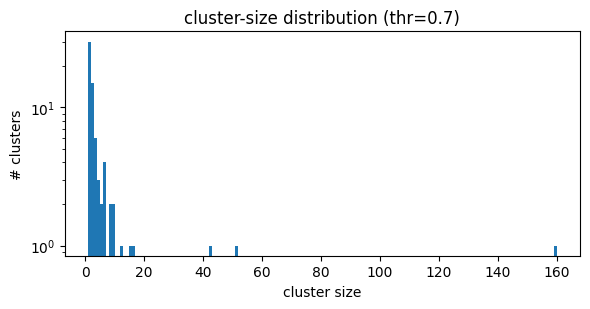

In [7]:
THRESHOLD = 0.70   # <- try 0.5, 0.7, 0.9 and re-run this + the next cell

clusters = cluster_at(S, THRESHOLD)
sizes = [len(c) for c in clusters]
print(f"THRESHOLD={THRESHOLD}: {len(clusters)} clusters | "
      f"sizes: max {max(sizes)}, median {int(np.median(sizes))}, singletons {sum(s==1 for s in sizes)}\n")

for rank, c in enumerate(clusters[:6], 1):
    names = [rows[i]["name"] for i in c]
    exs = ex_max[c]
    print(f"cluster {rank} (n={len(c)}, ex_max {exs.min():.0f}-{exs.max():.0f} nm): "
          f"{', '.join(names[:8])}{' ...' if len(names) > 8 else ''}")

if HAVE_PLT:
    plt.figure(figsize=(6, 3.2))
    plt.hist(sizes, bins=range(1, max(sizes)+2))
    plt.xlabel("cluster size"); plt.ylabel("# clusters"); plt.yscale("log")
    plt.title(f"cluster-size distribution (thr={THRESHOLD})"); plt.tight_layout(); plt.show()

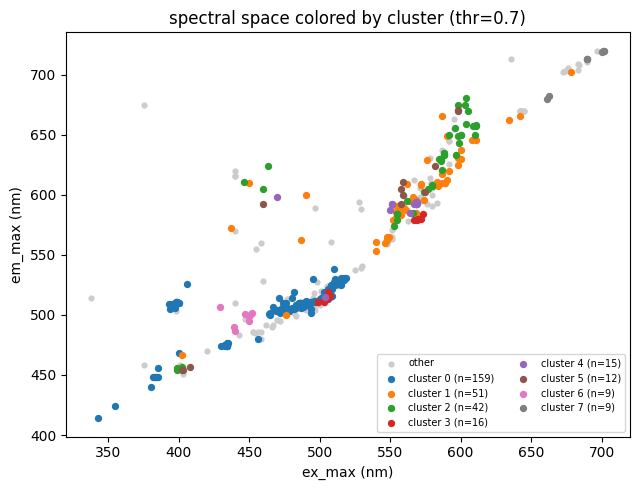

In [8]:
# Do the clusters occupy distinct spectral regions? Color the largest few; rest grey.
if HAVE_PLT:
    label = np.full(N, -1)
    for cid, c in enumerate(clusters):
        for i in c:
            label[i] = cid
    top = [cid for cid, _ in Counter(label.tolist()).most_common(8)]
    plt.figure(figsize=(6.5, 5))
    other = ~np.isin(label, top)
    plt.scatter(ex_max[other], em_max[other], s=12, c="0.8", label="other")
    for cid in top:
        m = label == cid
        plt.scatter(ex_max[m], em_max[m], s=18, label=f"cluster {cid} (n={m.sum()})")
    plt.xlabel("ex_max (nm)"); plt.ylabel("em_max (nm)")
    plt.title(f"spectral space colored by cluster (thr={THRESHOLD})")
    plt.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

## 5. Compare with other grouping schemes

Identity clusters are the principled choice, but it helps to compare against simpler groupings you might
split on instead: **name-family** (heuristic root of the protein name) and **source organism**.

In [9]:
def name_root(name):
    s = re.sub(r"[^A-Za-z0-9].*$", "", name)   # drop after first non-alphanumeric (e.g. "-I")
    s = re.sub(r"\d+$", "", s)                  # drop trailing version digits (mScarlet3 -> mScarlet)
    return s.lower() or name.lower()

fam = Counter(name_root(r["name"]) for r in rows)
org = Counter(r["parent_organism"] or "(unknown)" for r in rows)
print(f"name-family groups: {len(fam)} | top:", fam.most_common(8))
print(f"organism groups:    {len(org)} | top:", org.most_common(6))
print(f"identity clusters @ {THRESHOLD}: {len(clusters)}")
print("\nname-family is finer (more groups) but misses cross-named relatives; organism is very coarse.")

name-family groups: 262 | top: [('htfunclib', 68), ('mscarlet', 12), ('mirfp', 9), ('dsred', 6), ('mcherry', 6), ('meos', 6), ('mmaple', 6), ('irfp', 5)]
organism groups:    60 | top: [('Aequorea victoria', 158), ('Entacmaea quadricolor', 55), ('Discosoma sp.', 46), ('synthetic construct', 17), ('Lobophyllia hemprichii', 16), ('Rhodopseudomonas palustris', 13)]
identity clusters @ 0.7: 70

name-family is finer (more groups) but misses cross-named relatives; organism is very coarse.


## 6. Spot-check the proxy against true identity

Validate the k-mer proxy on a few real pairs using an exact (alignment-style) identity from `difflib`
(standard library). They should track: high-similarity pairs are genuinely high-identity.

In [10]:
from difflib import SequenceMatcher

def exact_identity(a, b):
    return SequenceMatcher(None, a, b).ratio()   # 2*matches/(len a+len b)

# pick the largest non-singleton cluster and check a few within-cluster pairs vs a cross-cluster pair
big = next(c for c in clusters if len(c) >= 2)
i0 = big[0]
print(f"reference: {rows[i0]['name']}")
print("within-cluster pairs (expect high):")
for j in big[1:4]:
    print(f"  vs {rows[j]['name']:>16}: kmer={S[i0,j]:.3f}  exact_identity={exact_identity(seqs[i0], seqs[j]):.3f}")
far = int(np.argmin(S[i0]))
print(f"most-dissimilar pair (expect low):")
print(f"  vs {rows[far]['name']:>16}: kmer={S[i0,far]:.3f}  exact_identity={exact_identity(seqs[i0], seqs[far]):.3f}")

reference: htFuncLib_fast.2
within-cluster pairs (expect high):
  vs htFuncLib_acid.5: kmer=0.940  exact_identity=0.637
  vs       PROSS-eGFP: kmer=0.927  exact_identity=0.694
  vs htFuncLib_acid.4: kmer=0.931  exact_identity=0.734
most-dissimilar pair (expect low):
  vs           smURFP: kmer=0.008  exact_identity=0.121


## 7. Preview a cluster-aware split (nothing is saved)

Given the clusters at the chosen threshold, hold out **whole clusters** for the test set until ~`test_frac`
of samples are reached, and check the test set still spans the spectral range. This is a *what-if* preview to
inform your decision — **it writes no files and commits no split.**

In [11]:
def preview_split(clusters, test_frac=0.2, seed=0):
    order = list(range(len(clusters)))
    np.random.default_rng(seed).shuffle(order)
    target = int(round(test_frac * N))
    test_idx, n_test_clusters = [], 0
    for ci in order:
        if len(test_idx) >= target:
            break
        test_idx += clusters[ci]; n_test_clusters += 1
    test_mask = np.zeros(N, bool); test_mask[test_idx] = True
    tr, te = ~test_mask, test_mask
    print(f"test_frac~{test_frac}: train {tr.sum()} ({len(clusters)-n_test_clusters} clusters) | "
          f"test {te.sum()} ({n_test_clusters} clusters)")
    print(f"  train ex {ex_max[tr].min():.0f}-{ex_max[tr].max():.0f}  em {em_max[tr].min():.0f}-{em_max[tr].max():.0f}")
    print(f"  test  ex {ex_max[te].min():.0f}-{ex_max[te].max():.0f}  em {em_max[te].min():.0f}-{em_max[te].max():.0f}")
    return tr, te

for seed in range(3):
    preview_split(clusters, test_frac=0.2, seed=seed)
    print()

test_frac~0.2: train 355 (51 clusters) | test 98 (19 clusters)
  train ex 338-702  em 414-720
  test  ex 398-697  em 454-720

test_frac~0.2: train 362 (38 clusters) | test 91 (32 clusters)
  train ex 343-702  em 414-720
  test  ex 338-697  em 451-720

test_frac~0.2: train 362 (38 clusters) | test 91 (32 clusters)
  train ex 338-697  em 414-720
  test  ex 375-702  em 454-720



## Notes & next step

- **No split is committed** — this notebook only explores. When you decide on a threshold and scheme, the
  splitter cell can be added to the FPbase design notebook (and a held-out forward model trained as the
  evaluation oracle).
- **For the production split**, recompute clusters with a proper aligner instead of the k-mer proxy, e.g.:
  ```bash
  mmseqs easy-cluster fpbase-extractor/processed_data/ESM-spectrum/sequences.fasta clu tmp \
      --min-seq-id 0.7 -c 0.8 --cov-mode 1
  # or: cd-hit -i sequences.fasta -o clu -c 0.7 -n 4
  ```
  Map cluster ids back to rows by `slug|state` (the fasta headers), then split by whole clusters.
- **Decision inputs:** threshold (how aggressively to merge families), test fraction, and whether to also
  stratify the test set across the spectral range or deliberately hold out a spectral region (extrapolation).